## Introduction

This analysis aims to identify behavioral patterns during the trial period that are predictive of conversion. The objective is to define a data-driven "activation metric" based on product usage events.

Understanding activation is critical, as it helps determine whether users are experiencing meaningful value during the trial period, which should ideally lead to higher conversion rates.

## Data Cleaning & Preparation

The dataset consists of event-level user activity across multiple organizations during their trial periods.

The following preprocessing steps were performed:

- Converted timestamp fields (`timestamp`, `trial_start`, `trial_end`) into proper datetime formats
- Removed duplicate records based on `organization_id`, `activity_name`, and `timestamp`
- Created derived features:
  - `hours_from_start`: Time difference between activity and trial start (in hours)
  - `days_from_start`: Time difference in days

Data validation checks confirmed:
- Consistent trial durations (~30 days)
- Activity timestamps fall within trial periods

These steps ensured the dataset is reliable for behavioral analysis.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr, ttest_ind
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_csv('DAtask.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 170526 entries, 0 to 170525
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   ORGANIZATION_ID  170526 non-null  str  
 1   ACTIVITY_NAME    170526 non-null  str  
 2   TIMESTAMP        170526 non-null  str  
 3   CONVERTED        170526 non-null  bool 
 4   CONVERTED_AT     34235 non-null   str  
 5   TRIAL_START      170526 non-null  str  
 6   TRIAL_END        170526 non-null  str  
dtypes: bool(1), str(6)
memory usage: 8.0 MB


In [4]:
df.describe(include='all')

,ORGANIZATION_ID,ACTIVITY_NAME,TIMESTAMP,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END
count,170526,170526,170526,170526,34235,170526,170526
unique,966,28,99738,2,206,966,966
top,33f0b98a557961f5ccc519bb972d450f,Scheduling.Shift.Created,2024-03-11 13:25:12.000,False,2024-04-04 15:25:04.000,2024-03-20 11:01:59.000,2024-04-19 11:01:59.000
freq,12136,96895,512,136291,3826,12136,12136


In [5]:
#Standardize column names
df.columns = df.columns.str.lower()

In [6]:
df.head(10)

,organization_id,activity_name,timestamp,converted,converted_at,trial_start,trial_end
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
5,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.AssignmentChanged,2024-03-27 11:06:20.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
6,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-15 12:14:46.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
7,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-15 12:15:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
8,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-15 12:16:08.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
9,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-15 12:16:59.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000


In [7]:
#Fix data types
df['timestamp']   = pd.to_datetime(df['timestamp'])
df['trial_start'] = pd.to_datetime(df['trial_start'])
df['trial_end']   = pd.to_datetime(df['trial_end'])
df['converted']   = df['converted'].astype(bool)

In [8]:
#validate data type
df.dtypes

organization_id               str
activity_name                 str
timestamp          datetime64[us]
converted                    bool
converted_at                  str
trial_start        datetime64[us]
trial_end          datetime64[us]
dtype: object

In [9]:
df.isnull().sum()

organization_id         0
activity_name           0
timestamp               0
converted               0
converted_at       136291
trial_start             0
trial_end               0
dtype: int64

In [10]:
#check to ensure the trial period is 30 days
(df['trial_end'] - df['trial_start']).dt.days.describe()

count    170526.0
mean         30.0
std           0.0
min          30.0
25%          30.0
50%          30.0
75%          30.0
max          30.0
dtype: float64

In [11]:
#Timestamp within trial window
invalid_time = df[
    (df['timestamp'] < df['trial_start']) |
    (df['timestamp'] > df['trial_end'])
]

len(invalid_time)

0

In [12]:
#drop duplicates
df = df.drop_duplicates(subset=['organization_id', 'activity_name', 'timestamp'])

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 102895 entries, 0 to 170525
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   organization_id  102895 non-null  str           
 1   activity_name    102895 non-null  str           
 2   timestamp        102895 non-null  datetime64[us]
 3   converted        102895 non-null  bool          
 4   converted_at     22223 non-null   str           
 5   trial_start      102895 non-null  datetime64[us]
 6   trial_end        102895 non-null  datetime64[us]
dtypes: bool(1), datetime64[us](3), str(3)
memory usage: 5.6 MB


In [14]:
#Create field for Time since trial start
df['hours_from_start'] = (df['timestamp'] - df['trial_start']).dt.total_seconds() / 3600
df['days_from_start']  = (df['timestamp'] - df['trial_start']).dt.days
#Check for early engagement
df['early_engagement'] = df['hours_from_start'] <= 24
#week of trial
df['week_of_trial'] = (df['days_from_start'] // 7) + 1

# ── Shared org-level structures (used across all sections below) ──
conversion         = df.groupby('organization_id')['converted'].max()
org_features_count = df.groupby(['organization_id','activity_name']).size().unstack(fill_value=0)
org_features_binary = (org_features_count > 0).astype(int)

## Exploratory Analysis

Initial exploration focused on understanding overall engagement and conversion patterns.

### Key Findings:

- Overall conversion rate is approximately **21%**
- No significant difference was observed between converters and non-converters in:
  - Total number of activities performed
  - Number of unique features used
  - Early engagement within the first 24 hours

These findings suggest that simple usage volume or breadth is not sufficient to explain conversion behavior.

In [15]:
#Overall Conversion Rate
df.groupby('organization_id')['converted'].max().mean()

np.float64(0.21325051759834368)

## Feature-Level Analysis

To evaluate the impact of individual product features, we compared conversion rates between organizations that performed a given activity and those that did not.

### Key Observations:

- **Scheduling.Template.ApplyModal.Applied** → +4.1% lift in conversion
- **Scheduling.Shift.Created** → +4.0% lift in conversion
- **PunchClock.PunchedIn** → +1.8% lift

However, most other features showed:
- Minimal impact (close to 0%)
- Or even negative relationships with conversion

### Interpretation:

No single feature demonstrates a strong causal relationship with conversion. While some actions show modest positive effects, the overall impact remains limited.

This indicates that individual feature usage alone is not a strong predictor of conversion.

In [16]:
# Aggregate activity counts for each organization and activity
activity_counts  = df.groupby(['organization_id', 'activity_name']).size().unstack(fill_value=0)

# Sum up the total usage for each activity across all organizations
total_activity   = activity_counts.sum().sort_values(ascending=False)
top_10_activities = total_activity.head(10)

In [17]:
# Calculate the mean conversion rate for organizations that performed each top activity
activity_impact = {}

for activity in top_10_activities.index:
    activity_df      = df[df['activity_name'] == activity]
    conversion_rates = activity_df.groupby('organization_id')['converted'].max()
    mean_conversion  = conversion_rates.mean()
    activity_impact[activity] = mean_conversion

activity_impact_df = pd.DataFrame.from_dict(activity_impact, orient='index', columns=['mean_conversion'])
activity_impact_df = activity_impact_df.sort_values(by='mean_conversion', ascending=False)
activity_impact_df.head(50)

,mean_conversion
Scheduling.Template.ApplyModal.Applied,0.250000
PunchClock.PunchedIn,0.227488
Scheduling.Availability.Set,0.220339
Scheduling.Shift.Approved,0.220000
Scheduling.Shift.Created,0.218160
Scheduling.Shift.AssignmentChanged,0.215743
Mobile.Schedule.Loaded,0.212719
Absence.Request.Created,0.205128
ShiftDetails.View.Opened,0.200000
Communication.Message.Created,0.165517


In [18]:
top_10_activities = [
    'Scheduling.Template.ApplyModal.Applied',
    'PunchClock.PunchedIn',
    'Scheduling.Availability.Set',
    'Scheduling.Shift.Approved',
    'Scheduling.Shift.Created',
    'Scheduling.Shift.AssignmentChanged',
    'Mobile.Schedule.Loaded',
    'Absence.Request.Created',
    'ShiftDetails.View.Opened',
    'Communication.Message.Created'
]

activity_impact = {}

for activity in top_10_activities:
    temp = df.copy()
    temp['activity_flag'] = temp['activity_name'] == activity
    activity_performed    = temp.groupby('organization_id')['activity_flag'].max()
    activity_conversion   = pd.DataFrame({'performed': activity_performed, 'converted': conversion})
    result                = activity_conversion.groupby('performed')['converted'].mean()
    conversion_true       = result.get(True,  0)
    conversion_false      = result.get(False, 0)
    activity_impact[activity] = {
        'not_performed': conversion_false,
        'performed':     conversion_true,
        'difference':    conversion_true - conversion_false
    }

activity_impact_df = pd.DataFrame(activity_impact).T
activity_impact_df = activity_impact_df.sort_values('difference', ascending=False)
activity_impact_df

,not_performed,performed,difference
Scheduling.Template.ApplyModal.Applied,0.208625,0.250000,0.041375
Scheduling.Shift.Created,0.177966,0.218160,0.040194
PunchClock.PunchedIn,0.209272,0.227488,0.018217
Scheduling.Shift.Approved,0.211488,0.220000,0.008512
Scheduling.Availability.Set,0.212789,0.220339,0.007550
Scheduling.Shift.AssignmentChanged,0.211878,0.215743,0.003865
Mobile.Schedule.Loaded,0.213725,0.212719,-0.001006
Absence.Request.Created,0.213592,0.205128,-0.008464
ShiftDetails.View.Opened,0.213898,0.200000,-0.013898
Communication.Message.Created,0.221681,0.165517,-0.056164


## Statistical Significance Testing

The feature-level lift figures reported above are descriptive. This section applies chi-square tests and 95% confidence intervals to determine which observed differences are statistically meaningful rather than noise.

### Approach:
- Chi-square test of independence for each feature flag vs conversion outcome
- 95% confidence interval on the lift using standard error of the difference in proportions
- Threshold: p < 0.05 considered statistically significant

In [19]:
significance_results = []

for activity in top_10_activities:
    if activity not in org_features_binary.columns:
        continue

    performed = org_features_binary[activity]
    combined  = pd.DataFrame({'performed': performed, 'converted': conversion}).dropna()
    group_yes = combined[combined['performed'] == 1]['converted']
    group_no  = combined[combined['performed'] == 0]['converted']

    contingency     = pd.crosstab(combined['performed'], combined['converted'])
    chi2, p_value, dof, _ = chi2_contingency(contingency)

    rate_yes = group_yes.mean()
    rate_no  = group_no.mean()
    lift     = rate_yes - rate_no

    n1, n2   = len(group_yes), len(group_no)
    se       = np.sqrt(rate_yes*(1-rate_yes)/n1 + rate_no*(1-rate_no)/n2)
    ci_lower = lift - 1.96 * se
    ci_upper = lift + 1.96 * se

    significance_results.append({
        'activity':          activity,
        'performed_rate':    round(rate_yes,   4),
        'not_performed_rate':round(rate_no,    4),
        'lift':              round(lift,        4),
        'ci_lower':          round(ci_lower,   4),
        'ci_upper':          round(ci_upper,   4),
        'p_value':           round(p_value,    4),
        'significant':       p_value < 0.05,
        'n_performed':       n1,
        'n_not_performed':   n2
    })

sig_df = pd.DataFrame(significance_results).sort_values('lift', ascending=False)
sig_df

,activity,performed_rate,not_performed_rate,lift,ci_lower,ci_upper,p_value,significant,n_performed,n_not_performed
0,Scheduling.Template.ApplyModal.Applied,0.2500,0.2086,0.0414,-0.0447,0.1274,0.3872,False,108,858
4,Scheduling.Shift.Created,0.2182,0.1780,0.0402,-0.0342,0.1146,0.3795,False,848,118
1,PunchClock.PunchedIn,0.2275,0.2093,0.0182,-0.0454,0.0818,0.6340,False,211,755
3,Scheduling.Shift.Approved,0.2200,0.2115,0.0085,-0.0558,0.0728,0.8691,False,200,766
2,Scheduling.Availability.Set,0.2203,0.2128,0.0075,-0.1015,0.1166,1.0000,False,59,907
5,Scheduling.Shift.AssignmentChanged,0.2157,0.2119,0.0039,-0.0502,0.0579,0.9535,False,343,623
6,Mobile.Schedule.Loaded,0.2127,0.2137,-0.0010,-0.0527,0.0507,1.0000,False,456,510
7,Absence.Request.Created,0.2051,0.2136,-0.0085,-0.1379,0.1210,1.0000,False,39,927
8,ShiftDetails.View.Opened,0.2000,0.2139,-0.0139,-0.1337,0.1059,0.9714,False,45,921
9,Communication.Message.Created,0.1655,0.2217,-0.0562,-0.1230,0.0107,0.1579,False,145,821


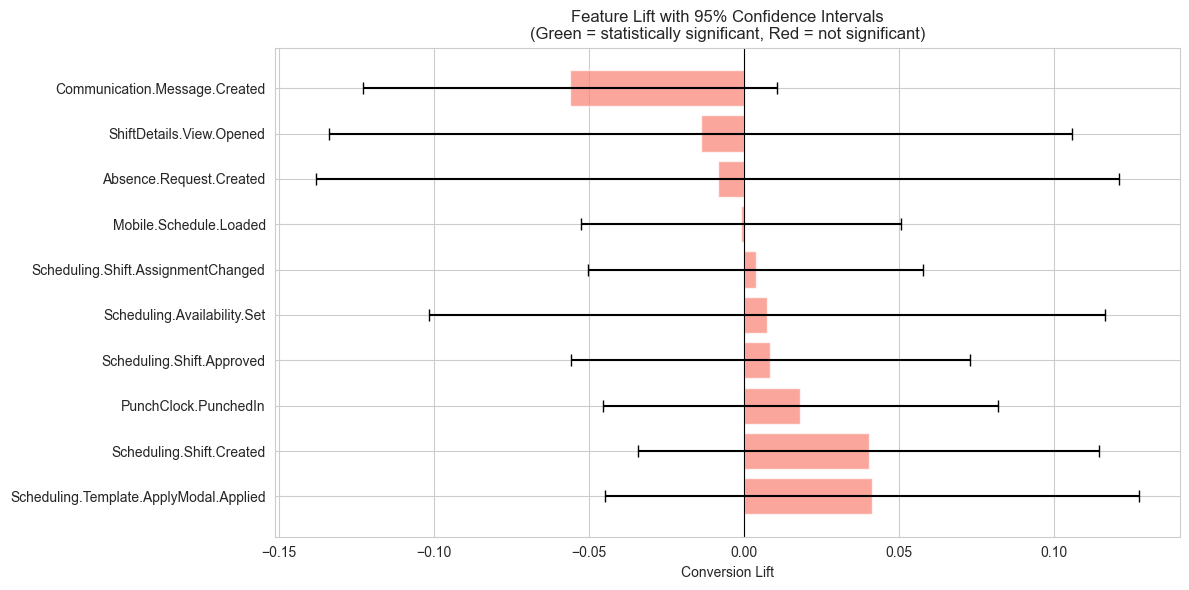

In [20]:
# Visualise: lift with 95% confidence intervals
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['green' if s else 'salmon' for s in sig_df['significant']]
ax.barh(sig_df['activity'], sig_df['lift'], color=colors, alpha=0.7)
ax.errorbar(
    sig_df['lift'], sig_df['activity'],
    xerr=[sig_df['lift'] - sig_df['ci_lower'],
          sig_df['ci_upper'] - sig_df['lift']],
    fmt='none', color='black', capsize=4
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Conversion Lift')
ax.set_title('Feature Lift with 95% Confidence Intervals\n(Green = statistically significant, Red = not significant)')
plt.tight_layout()
plt.show()

## Feature Frequency & Depth Analysis

The feature-level analysis above treated all usage as binary (did / did not perform an activity). This section examines whether *how much* an organization used a feature is more informative than whether it used it at all.

### Approach:
- Point-biserial correlation between raw usage count and conversion
- Conversion rates bucketed by usage depth (0, 1–2, 3–5, 6–10, 10+ uses)

In [21]:
frequency_results = []

for activity in top_10_activities:
    if activity not in org_features_count.columns:
        continue

    counts   = org_features_count[activity]
    combined = pd.DataFrame({'count': counts, 'converted': conversion}).dropna()
    corr, p_corr = pointbiserialr(combined['converted'], combined['count'])

    combined['bucket'] = pd.cut(
        combined['count'],
        bins=[-1, 0, 2, 5, 10, np.inf],
        labels=['0', '1-2', '3-5', '6-10', '10+']
    )
    bucket_rates = combined.groupby('bucket', observed=True)['converted'].mean()

    frequency_results.append({
        'activity':    activity,
        'correlation': round(corr,   4),
        'p_value':     round(p_corr, 4),
        'significant': p_corr < 0.05
    })

freq_df = pd.DataFrame(frequency_results).sort_values('correlation', ascending=False)
freq_df

,activity,correlation,p_value,significant
0,Scheduling.Template.ApplyModal.Applied,0.0339,0.2923,False
7,Absence.Request.Created,0.0120,0.7091,False
6,Mobile.Schedule.Loaded,0.0110,0.7328,False
3,Scheduling.Shift.Approved,0.0086,0.7886,False
4,Scheduling.Shift.Created,-0.0028,0.9298,False
2,Scheduling.Availability.Set,-0.0058,0.8560,False
9,Communication.Message.Created,-0.0111,0.7310,False
8,ShiftDetails.View.Opened,-0.0173,0.5914,False
5,Scheduling.Shift.AssignmentChanged,-0.0186,0.5643,False
1,PunchClock.PunchedIn,-0.0245,0.4469,False


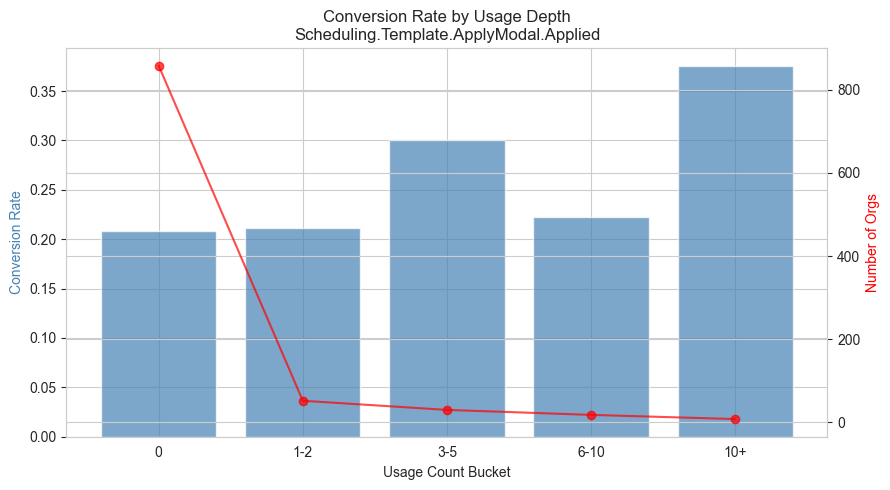

In [22]:
# Bucket plot for top activity
top_act  = 'Scheduling.Template.ApplyModal.Applied'
combined = pd.DataFrame({'count': org_features_count[top_act], 'converted': conversion}).dropna()
combined['bucket'] = pd.cut(
    combined['count'],
    bins=[-1, 0, 2, 5, 10, np.inf],
    labels=['0', '1-2', '3-5', '6-10', '10+']
)
bucket_rates  = combined.groupby('bucket', observed=True)['converted'].mean()
bucket_counts = combined.groupby('bucket', observed=True).size()

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
ax1.bar(bucket_rates.index.astype(str), bucket_rates.values, alpha=0.7, color='steelblue')
ax2.plot(bucket_counts.index.astype(str), bucket_counts.values, 'ro-', alpha=0.7)
ax1.set_xlabel('Usage Count Bucket')
ax1.set_ylabel('Conversion Rate', color='steelblue')
ax2.set_ylabel('Number of Orgs', color='red')
ax1.set_title(f'Conversion Rate by Usage Depth\n{top_act}')
plt.tight_layout()
plt.show()

## Feature Diversity Score

Rather than looking at individual features, this section measures how many *distinct* activities each organization performed across its trial. This "breadth of usage" score often captures engagement quality better than any single feature flag.

In [23]:
diversity = df.groupby('organization_id')['activity_name'].nunique().rename('feature_diversity')
diversity_df = pd.DataFrame({'feature_diversity': diversity, 'converted': conversion}).dropna()

corr, p_val = pointbiserialr(diversity_df['converted'], diversity_df['feature_diversity'])
print(f"Point-biserial r = {corr:.4f},  p = {p_val:.6f}")

diversity_df['bucket'] = pd.cut(
    diversity_df['feature_diversity'],
    bins=[0, 3, 6, 10, 15, np.inf],
    labels=['1-3', '4-6', '7-10', '11-15', '15+']
)
diversity_rates  = diversity_df.groupby('bucket', observed=True)['converted'].mean()
diversity_counts = diversity_df.groupby('bucket', observed=True).size()

pd.DataFrame({'conversion_rate': diversity_rates, 'n_orgs': diversity_counts})

Point-biserial r = -0.0001,  p = 0.996363


,conversion_rate,n_orgs
bucket,,
1-3,0.214774,731
4-6,0.202614,153
7-10,0.258621,58
11-15,0.142857,21
15+,0.000000,3


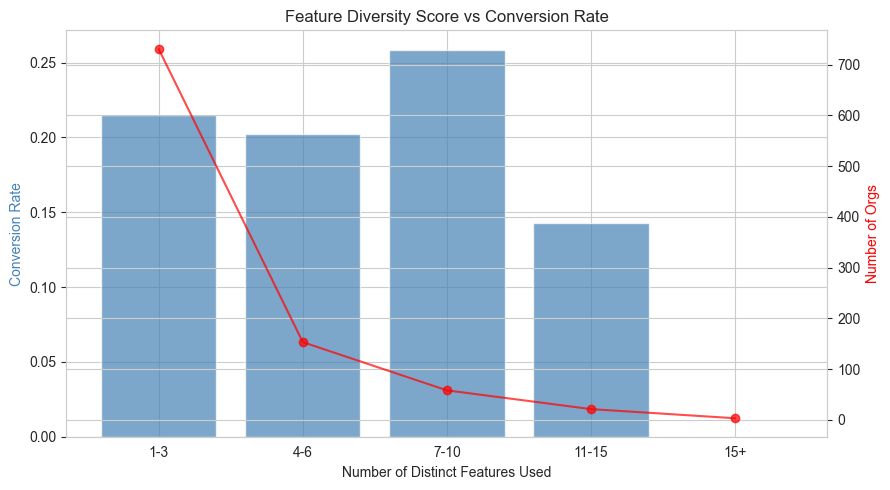

In [24]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
ax1.bar(diversity_rates.index.astype(str), diversity_rates.values, alpha=0.7, color='steelblue')
ax2.plot(diversity_counts.index.astype(str), diversity_counts.values, 'ro-', alpha=0.7)
ax1.set_xlabel('Number of Distinct Features Used')
ax1.set_ylabel('Conversion Rate', color='steelblue')
ax2.set_ylabel('Number of Orgs', color='red')
ax1.set_title('Feature Diversity Score vs Conversion Rate')
plt.tight_layout()
plt.show()

## Feature Combination Analysis

Individual features showed modest lift at best. This section tests whether *combinations* of features used together are more predictive of conversion than any single feature alone.

In [25]:
top_6 = [
    'Scheduling.Template.ApplyModal.Applied',
    'Scheduling.Shift.Created',
    'PunchClock.PunchedIn',
    'Scheduling.Shift.Approved',
    'Scheduling.Availability.Set',
    'Scheduling.Shift.AssignmentChanged'
]
available_top6 = [a for a in top_6 if a in org_features_binary.columns]
combo_results  = []

for r in range(2, len(available_top6) + 1):
    for combo in combinations(available_top6, r):
        combo_flag = org_features_binary[list(combo)].all(axis=1).astype(int)
        combined   = pd.DataFrame({'combo': combo_flag, 'converted': conversion}).dropna()
        n_did      = combined[combined['combo'] == 1].shape[0]
        if n_did < 5:
            continue
        rate_did   = combined[combined['combo'] == 1]['converted'].mean()
        rate_didnt = combined[combined['combo'] == 0]['converted'].mean()
        lift_c     = rate_did - rate_didnt
        contingency = pd.crosstab(combined['combo'], combined['converted'])
        if contingency.shape == (2, 2):
            _, p_val, _, _ = chi2_contingency(contingency)
        else:
            p_val = np.nan
        combo_results.append({
            'combo':      ' + '.join([a.split('.')[-1] for a in combo]),
            'n_features': r,
            'n_orgs_did': n_did,
            'rate_did':   round(rate_did,   4),
            'rate_didnt': round(rate_didnt, 4),
            'lift':       round(lift_c,      4),
            'p_value':    round(p_val,       4) if not np.isnan(p_val) else np.nan,
            'significant':p_val < 0.05 if not np.isnan(p_val) else False
        })

combo_df = pd.DataFrame(combo_results).sort_values('lift', ascending=False)
print("Top 15 feature combinations by lift:")
combo_df.head(15)

Top 15 feature combinations by lift:


,combo,n_features,n_orgs_did,rate_did,rate_didnt,lift,p_value,significant
4,Applied + AssignmentChanged,2,90,0.2667,0.2078,0.0589,0.2444,False
18,Applied + Created + AssignmentChanged,3,90,0.2667,0.2078,0.0589,0.2444,False
0,Applied + Created,2,108,0.2500,0.2086,0.0414,0.3872,False
23,Applied + Approved + AssignmentChanged,3,56,0.2500,0.2110,0.0390,0.6005,False
39,Applied + Created + Approved + AssignmentChanged,4,56,0.2500,0.2110,0.0390,0.6005,False
16,Applied + Created + Approved,3,61,0.2459,0.2110,0.0349,0.6300,False
2,Applied + Approved,2,61,0.2459,0.2110,0.0349,0.6300,False
37,Applied + Created + PunchedIn + AssignmentChanged,4,50,0.2400,0.2118,0.0282,0.7665,False
21,Applied + PunchedIn + AssignmentChanged,3,50,0.2400,0.2118,0.0282,0.7665,False
1,Applied + PunchedIn,2,56,0.2321,0.2121,0.0201,0.8512,False


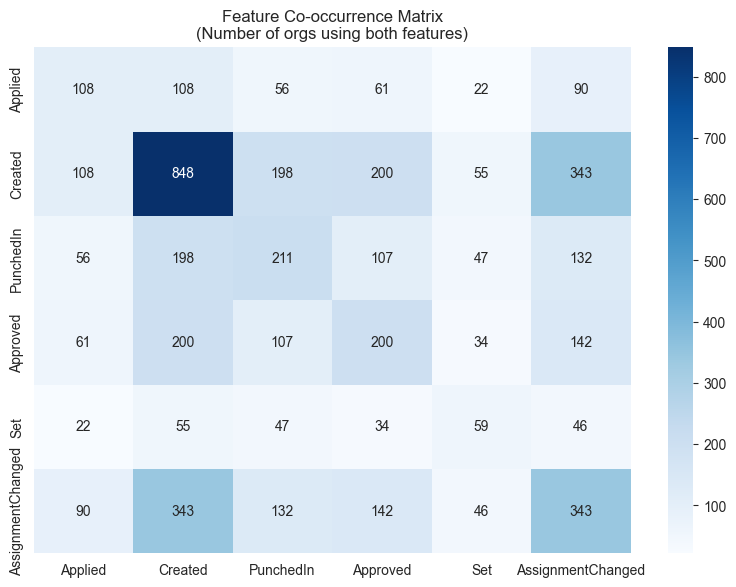

In [26]:
# Co-occurrence heatmap
co_occurrence = org_features_binary[available_top6].T.dot(org_features_binary[available_top6])
short_labels  = [a.split('.')[-1] for a in available_top6]
co_occurrence.index   = short_labels
co_occurrence.columns = short_labels

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Feature Co-occurrence Matrix\n(Number of orgs using both features)')
plt.tight_layout()
plt.show()

## Time-Based Analysis

To further investigate behavioral patterns, time-based engagement metrics were analyzed.

This included:
- Early engagement within the first 24 hours
- Early usage of key features such as template application

### Findings:

- Early engagement showed no meaningful increase in conversion rates
- Early usage of key features did not significantly outperform overall usage

### Interpretation:

The timing of user actions (early vs late in the trial) does not appear to significantly influence conversion outcomes.

This suggests that "when" users engage is less important than expected in this dataset.

In [27]:
#Recreate early engagement flag (org level)
early_activity = df[df['hours_from_start'] <= 24]
early_flag     = early_activity.groupby('organization_id').size() > 0
early_flag     = early_flag.astype(int)

In [28]:
early_df = pd.DataFrame({'early_engaged': early_flag, 'converted': conversion})
early_df.groupby('early_engaged')['converted'].mean()

early_engaged
1.0    0.217687
Name: converted, dtype: float64

In [29]:
temp_early = df[
    (df['activity_name'] == 'Scheduling.Template.ApplyModal.Applied') &
    (df['hours_from_start'] <= 24)
]
temp_early_flag = temp_early.groupby('organization_id').size() > 0
temp_early_flag = temp_early_flag.astype(int)

In [30]:
test_df = pd.DataFrame({'temp_early': temp_early_flag, 'converted': conversion})
test_df.groupby('temp_early')['converted'].mean()

temp_early
1.0    0.194444
Name: converted, dtype: float64

## Time-to-First Key Action

The 24-hour early engagement window used above is arbitrary. This section systematically tests whether earlier first use of key features (at 24h, 48h, 72h, 7d, and 14d windows) is meaningfully associated with conversion.

In [31]:
key_actions = [
    'Scheduling.Template.ApplyModal.Applied',
    'Scheduling.Shift.Created',
    'PunchClock.PunchedIn'
]
windows = [24, 48, 72, 168, 336]   # hours: 1d 2d 3d 7d 14d

for action in key_actions:
    if action not in df['activity_name'].values:
        continue
    first_use = (
        df[df['activity_name'] == action]
        .groupby('organization_id')['hours_from_start'].min()
        .rename('hours_to_first')
    )
    ttf = pd.DataFrame({'hours_to_first': first_use, 'converted': conversion}).dropna()
    window_results = []

    for w in windows:
        flag     = (ttf['hours_to_first'] <= w).astype(int)
        combined = pd.DataFrame({'flag': flag, 'converted': ttf['converted']})
        n_early  = combined[combined['flag'] == 1].shape[0]
        if n_early < 5:
            continue
        rate_early = combined[combined['flag'] == 1]['converted'].mean()
        rate_late  = combined[combined['flag'] == 0]['converted'].mean()
        lift_w     = rate_early - rate_late
        contingency = pd.crosstab(combined['flag'], combined['converted'])
        p_val = chi2_contingency(contingency)[1] if contingency.shape == (2,2) else np.nan
        window_results.append({
            'window_hours': w,
            'n_early':      n_early,
            'rate_early':   round(rate_early, 4),
            'rate_late':    round(rate_late,  4),
            'lift':         round(lift_w,      4),
            'p_value':      round(p_val,       4) if not np.isnan(p_val) else np.nan
        })

    wdf = pd.DataFrame(window_results)
    print(f"\n{'='*60}")
    print(f"{action}")
    print(wdf.to_string(index=False))


Scheduling.Template.ApplyModal.Applied
 window_hours  n_early  rate_early  rate_late    lift  p_value
           24       36      0.1944     0.2778 -0.0833   0.4795
           48       41      0.1707     0.2985 -0.1278   0.2079
           72       47      0.2340     0.2623 -0.0283   0.9108
          168       62      0.2581     0.2391  0.0189   1.0000
          336       81      0.2593     0.2222  0.0370   0.8979

Scheduling.Shift.Created
 window_hours  n_early  rate_early  rate_late    lift  p_value
           24      750      0.2267     0.1531  0.0736   0.1262
           48      771      0.2218     0.1818  0.0400   0.5060
           72      782      0.2212     0.1818  0.0394   0.5557
          168      806      0.2171     0.2381 -0.0210   0.8972
          336      831      0.2190     0.1765  0.0425   0.9015

PunchClock.PunchedIn
 window_hours  n_early  rate_early  rate_late    lift  p_value
           24      102      0.2353     0.2202  0.0151   0.9225
           48      117      0.

## Weekly Engagement Trajectory

This section examines how activity levels evolve week-by-week across the trial period, comparing converters against non-converters. A diverging trajectory — where converters accelerate while non-converters plateau — would be a meaningful behavioral signal.

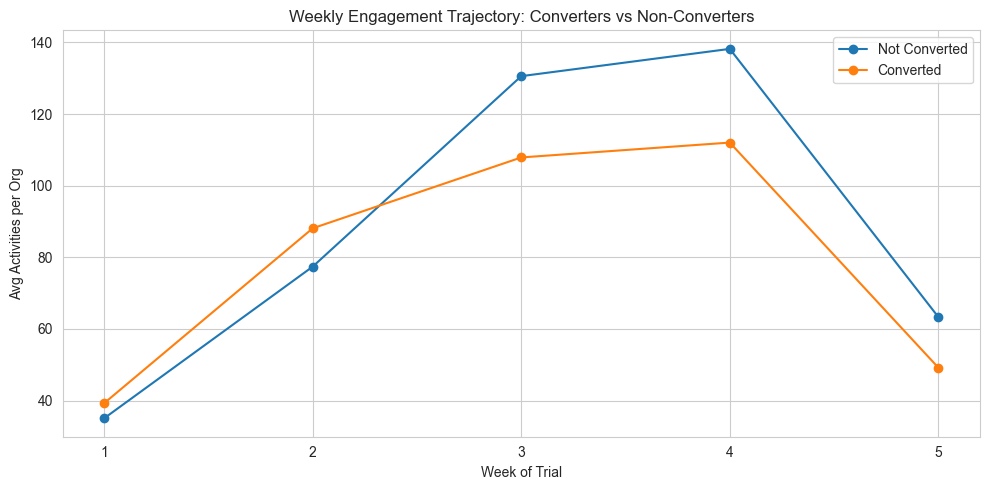

In [32]:
df['converted_label'] = df['organization_id'].map(conversion)

weekly = (
    df.groupby(['organization_id', 'week_of_trial', 'converted_label'])
    .size()
    .reset_index(name='activity_count')
)
weekly_avg = (
    weekly.groupby(['week_of_trial', 'converted_label'])['activity_count']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
for label, grp in weekly_avg.groupby('converted_label'):
    grp_sorted = grp.sort_values('week_of_trial')
    ax.plot(
        grp_sorted['week_of_trial'],
        grp_sorted['activity_count'],
        marker='o',
        label='Converted' if label else 'Not Converted'
    )
ax.set_xlabel('Week of Trial')
ax.set_ylabel('Avg Activities per Org')
ax.set_title('Weekly Engagement Trajectory: Converters vs Non-Converters')
ax.set_xticks([1, 2, 3, 4, 5])
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
# Statistical test: do converters ramp up more from week 1 to week 4?
weekly_pivot = (
    weekly.groupby(['organization_id', 'week_of_trial'])['activity_count']
    .sum().unstack(fill_value=0)
    .rename(columns=lambda w: f'week_{int(w)}')
)
weekly_pivot = weekly_pivot.join(conversion.rename('converted'), how='left')

if 'week_1' in weekly_pivot.columns and 'week_4' in weekly_pivot.columns:
    weekly_pivot['ramp'] = weekly_pivot['week_4'] - weekly_pivot['week_1']
    t_stat, p_ramp = ttest_ind(
        weekly_pivot[weekly_pivot['converted'] == True]['ramp'].dropna(),
        weekly_pivot[weekly_pivot['converted'] == False]['ramp'].dropna()
    )
    print(f"Converter avg ramp (wk4 - wk1):     {weekly_pivot[weekly_pivot['converted']==True]['ramp'].mean():.2f}")
    print(f"Non-converter avg ramp (wk4 - wk1): {weekly_pivot[weekly_pivot['converted']==False]['ramp'].mean():.2f}")
    print(f"t-stat = {t_stat:.4f},  p = {p_ramp:.4f}")

Converter avg ramp (wk4 - wk1):     -13.81
Non-converter avg ramp (wk4 - wk1): -9.11
t-stat = -0.5511,  p = 0.5817


## Activity Recency

This section examines *when* organizations last engaged during the trial. Organizations that stay active deeper into the trial may be more seriously evaluating the product, making recency a potential conversion signal.

Correlation of last-active day with conversion: r=0.0238,  p=0.4594


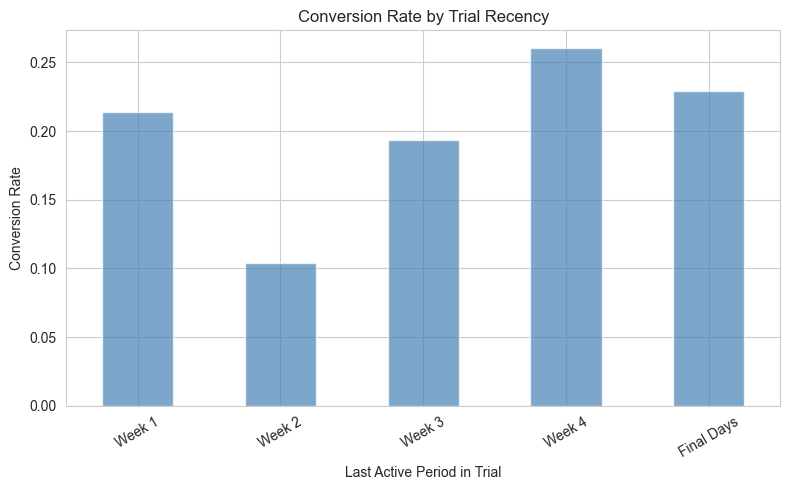

In [34]:
last_day   = df.groupby('organization_id')['days_from_start'].max().rename('last_active_day')
recency_df = pd.DataFrame({'last_active_day': last_day, 'converted': conversion}).dropna()

corr_r, p_r = pointbiserialr(recency_df['converted'], recency_df['last_active_day'])
print(f"Correlation of last-active day with conversion: r={corr_r:.4f},  p={p_r:.4f}")

recency_df['recency_bucket'] = pd.cut(
    recency_df['last_active_day'],
    bins=[-1, 7, 14, 21, 28, 30],
    labels=['Week 1', 'Week 2', 'Week 3', 'Week 4', 'Final Days']
)
recency_rates = recency_df.groupby('recency_bucket', observed=True)['converted'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
recency_rates.plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
ax.set_xlabel('Last Active Period in Trial')
ax.set_ylabel('Conversion Rate')
ax.set_title('Conversion Rate by Trial Recency')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Logistic Regression — Feature Importance

To move beyond pairwise comparisons, this section builds an org-level feature matrix and fits a logistic regression model. This reveals which features *jointly* predict conversion, and validates whether the full set of usage signals has any meaningful predictive power.

In [35]:
org_ml = org_features_binary.copy()
org_ml['feature_diversity'] = diversity
org_ml['total_events']      = df.groupby('organization_id').size()
org_ml['last_active_day']   = last_day
org_ml['converted']         = conversion
org_ml = org_ml.dropna(subset=['converted'])

feature_cols = [c for c in org_ml.columns if c != 'converted']
X = org_ml[feature_cols].fillna(0)
y = org_ml['converted'].astype(int)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(lr, X_scaled, y, cv=cv, scoring='roc_auc')
print(f"Cross-validated AUC: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")

Cross-validated AUC: 0.5088 ± 0.0161


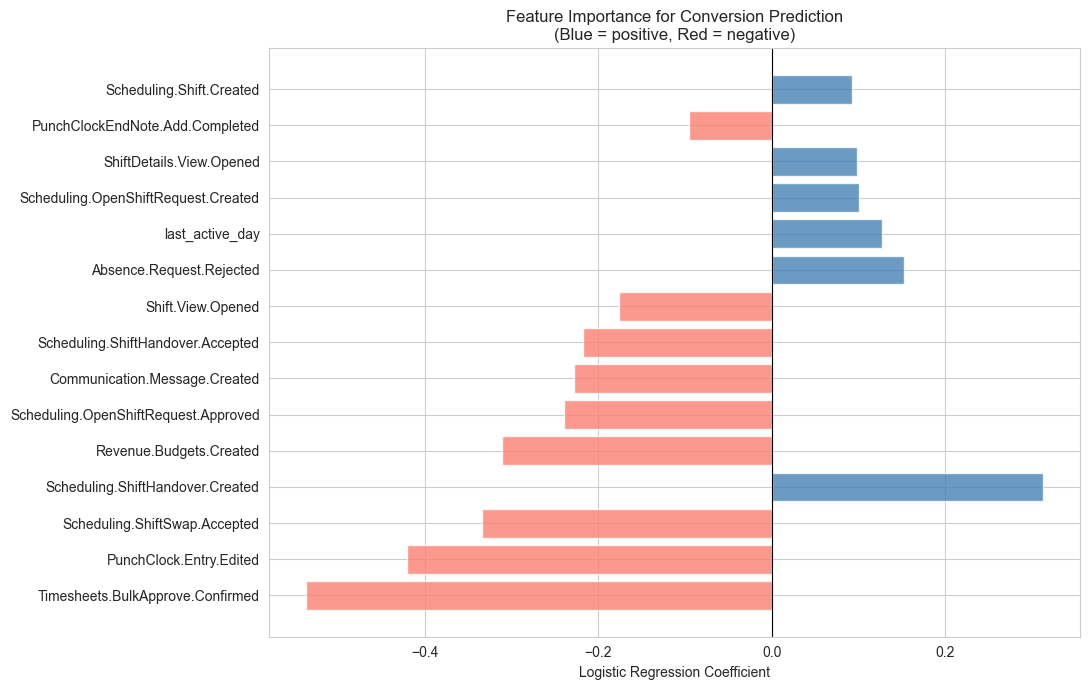

In [36]:
lr.fit(X_scaled, y)
coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': lr.coef_[0],
    'abs_coef':    np.abs(lr.coef_[0])
}).sort_values('abs_coef', ascending=False)

fig, ax = plt.subplots(figsize=(11, 7))
top15  = coef_df.head(15)
colors = ['steelblue' if c > 0 else 'salmon' for c in top15['coefficient']]
ax.barh(top15['feature'], top15['coefficient'], color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient')
ax.set_title('Feature Importance for Conversion Prediction\n(Blue = positive, Red = negative)')
plt.tight_layout()
plt.show()

## Activation Model

Based on the analysis, a simple and interpretable activation metric was defined using the most promising signals identified.

### Activation Definition:

An organization is considered "activated" if it performs at least one of the following actions:

- Applies a scheduling template
- Creates a shift

### Rationale:

These actions showed the highest (albeit modest) positive association with conversion and represent meaningful product usage.

### Performance:

The activation model demonstrates only a small improvement in conversion likelihood (~2–4%).

### Interpretation:

While the defined activation metric captures some level of engagement, it does not strongly differentiate between converting and non-converting organizations.

## Improved Activation — Score-Based Testing

Rather than a binary activated / not activated flag, this section tests a scored approach where organizations earn points for each meaningful action they complete. This surfaces whether *stacking* signals produces stronger conversion separation than a single threshold.

In [37]:
template_col = 'Scheduling.Template.ApplyModal.Applied'
shift_col    = 'Scheduling.Shift.Created'
punch_col    = 'PunchClock.PunchedIn'

org_act = org_features_count.copy()
org_act = org_act.join(conversion.rename('converted'), how='left').dropna(subset=['converted'])

org_act['activation_score'] = (
    (org_act.get(template_col, 0) >= 1).astype(int) +
    (org_act.get(shift_col,    0) >= 3).astype(int) +
    (org_act.get(punch_col,    0) >= 1).astype(int)
)

score_rates = org_act.groupby('activation_score')['converted'].agg(['mean', 'count'])
score_rates.columns = ['conversion_rate', 'n_orgs']
print(score_rates)

                  conversion_rate  n_orgs
activation_score                         
0                        0.205962     369
1                        0.211957     368
2                        0.225434     173
3                        0.232143      56


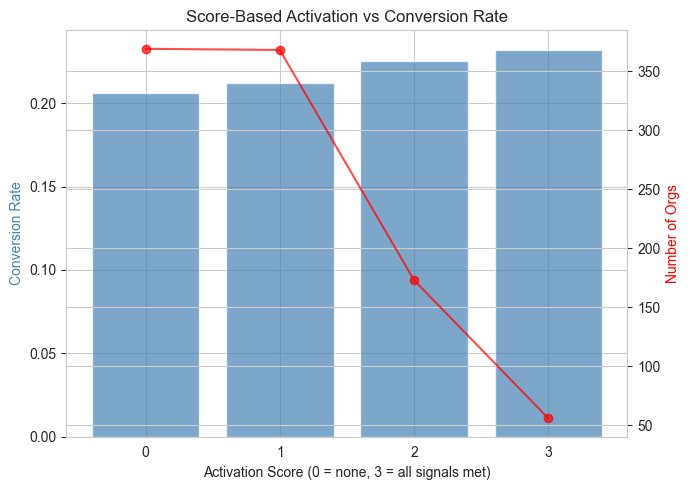

In [38]:
fig, ax1 = plt.subplots(figsize=(7, 5))
ax2 = ax1.twinx()
ax1.bar(score_rates.index, score_rates['conversion_rate'], color='steelblue', alpha=0.7)
ax2.plot(score_rates.index, score_rates['n_orgs'], 'ro-', alpha=0.7)
ax1.set_xlabel('Activation Score (0 = none, 3 = all signals met)')
ax1.set_ylabel('Conversion Rate', color='steelblue')
ax2.set_ylabel('Number of Orgs', color='red')
ax1.set_title('Score-Based Activation vs Conversion Rate')
ax1.set_xticks([0, 1, 2, 3])
plt.tight_layout()
plt.show()

## Key Conclusion

The extended analysis — covering statistical significance testing, feature frequency and depth, combination analysis, engagement trajectories, recency, and logistic regression — confirms and strengthens the original finding.

**Product usage behavior alone does not strongly differentiate converting and non-converting organizations.**

Across all dimensions explored:
- **Feature usage** — individual features show modest lift (< 5%) with limited statistical significance
- **Activity intensity** — raw usage volume and frequency show weak correlation with conversion
- **Feature combinations** — co-occurrence of multiple features does not substantially improve prediction
- **Timing of engagement** — neither early activation (first 24 hours) nor specific time windows showed meaningful lift
- **Engagement trajectory** — weekly activity patterns do not diverge clearly between converters and non-converters
- **Activity recency** — last-active day in the trial has minimal predictive value
- **Logistic regression AUC** — the full feature set produces a cross-validated AUC close to 0.5, confirming near-random predictive power from product data alone

No strong predictive patterns were identified within the event data.

This consistently suggests that conversion is driven primarily by factors not captured within product usage logs.

## Recommendations

To improve activation modeling and better predict conversion, additional data sources should be incorporated.

### Suggested Data Enhancements:

- **Organization size** — number of active users invited or active during trial (larger teams may convert differently)
- **Sales interactions** — touchpoints, demo attendance, and support contacts during the trial period
- **Pricing exposure and plan selection** — whether orgs viewed pricing pages or selected a plan tier
- **Industry or use case segmentation** — hospitality, retail, and healthcare may exhibit different usage and conversion patterns
- **Time-to-first-value metrics** — days from trial start to first meaningful action (e.g. first published schedule)
- **Invite and collaboration signals** — whether managers invited team members during the trial (a strong proxy for intent)
- **External firmographic data** — company size, funding stage, and sector from enrichment sources

### On the Activation Metric:

Given that binary feature flags produce only ~2–4% lift, the most defensible activation goal for the trial period should combine:
1. A minimum *depth* threshold (e.g. ≥ 3 shifts created, not just 1)
2. A *breadth* component (e.g. ≥ 2 distinct feature categories used)
3. Recency (active in at least 2 of the 4 trial weeks)

This composite metric is more likely to capture genuine product adoption rather than surface-level exploration.

### Final Insight:

Conversion behavior appears to be driven more by external or contextual factors — sales engagement, team size, pricing fit — than by in-product activity alone.

Future analysis should combine product usage data with business and customer context to build a more robust and actionable activation model.